# MLDM Week 7 Workshop: Feature Selection & Class Imbalance

**University of Salford, MSc Data Science**  
**Module:** Machine Learning & Data Mining  
**Session:** Workshop Week 7  
**Topic:** Feature Selection & Class Imbalance  
**Tools:** Jupyter Notebook

## Objectives:

After completing this workshop, you will be able to:

- Use filter methods for feature selection (using the VarianceThreshold and SelectKBest selectors in Scikit Learn)
- Use wrapper methods for feature selection (such as Recursive Feature Elimination)
- Understand the problem of class imbalance and use the imblearn package for resampling, including oversampling, undersampling and SMOTE.
- Use the imshow function from matplotlib to visualise images stored as a Numpy array

## Part One: Exploring the Data

In [1]:
# Run the imports we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Load MNIST data
mnist = np.genfromtxt('MNIST_Shortened.csv', delimiter=',', skip_header=1)

# Define X and y
X = mnist[:,0:784]
y = mnist[:,-1]

# Check dimensions of X
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6000, 784)
y shape: (6000,)


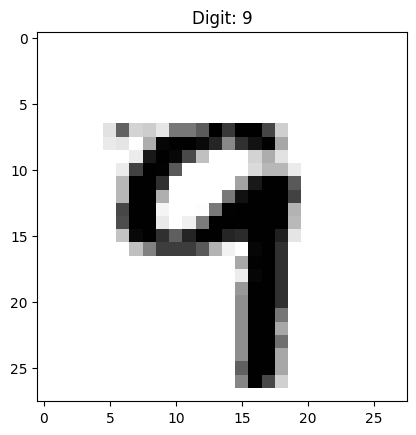

In [3]:
# Visualize first image
plt.imshow(X[0].reshape(28,28), cmap='gray_r')
plt.title(f"Digit: {int(y[0])}")
plt.show()

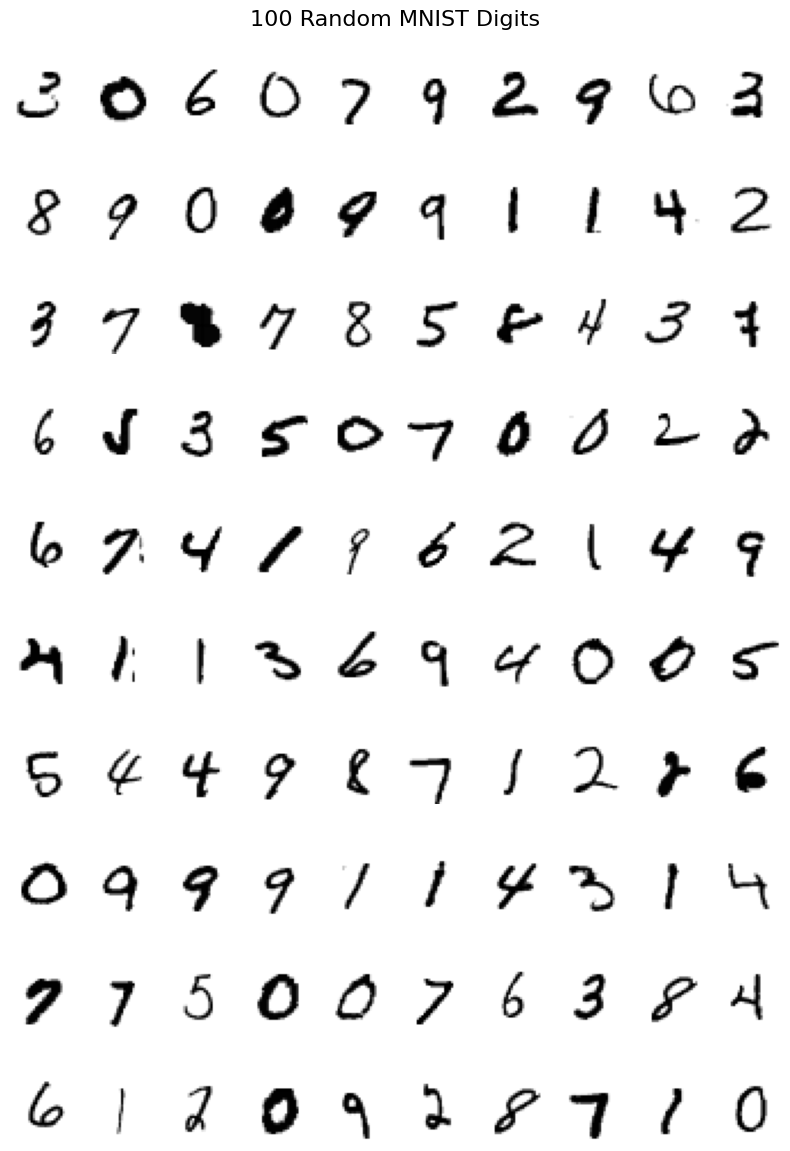

In [4]:
# Visualize 100 random images
plt.figure(figsize=(8, 12))
for i in range(100):
    plt.subplot(10,10,i+1)
    random_index = np.random.randint(0,6000)
    plt.imshow(X[random_index].reshape(28,28), cmap='gray_r')
    plt.axis('off')
plt.suptitle("100 Random MNIST Digits", fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (4200, 784)
Test set shape: (1800, 784)


## Part Two: Using VarianceThreshold to remove low or no variance features

In [6]:
from sklearn.feature_selection import VarianceThreshold

# Remove zero variance features
variance_selector = VarianceThreshold(threshold=0)
X_train_fs = variance_selector.fit_transform(X_train)
X_test_fs = variance_selector.transform(X_test)

print(f"{X_train.shape[1]-X_train_fs.shape[1]} features have been removed, {X_train_fs.shape[1]} features remain")

118 features have been removed, 666 features remain


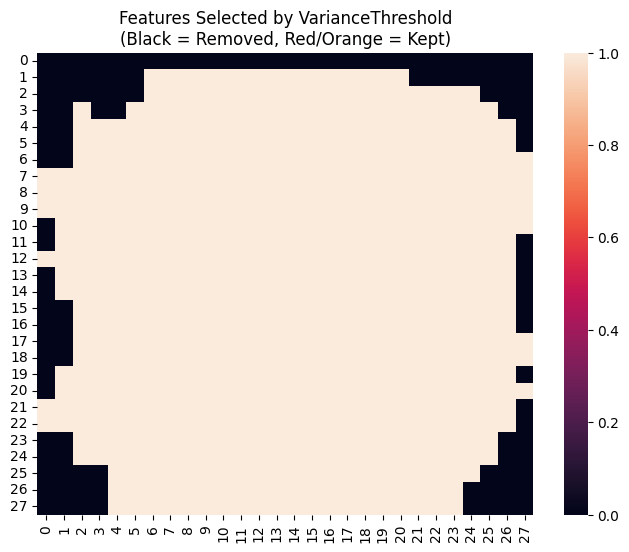

In [7]:
# Visualize which features were kept
selected_features = variance_selector.get_support().reshape(28,28)

plt.figure(figsize=(8, 6))
sns.heatmap(selected_features, cmap='rocket')
plt.title("Features Selected by VarianceThreshold\n(Black = Removed, Red/Orange = Kept)")
plt.show()

## Part Three: Filter Methods Using SelectKBest

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 200 features using ANOVA F-value
selector = SelectKBest(f_classif, k=200)
X_train_fs = selector.fit_transform(X_train_fs, y_train)
X_test_fs = selector.transform(X_test_fs)

print(f"After SelectKBest - Training set shape: {X_train_fs.shape}")

After SelectKBest - Training set shape: (4200, 200)


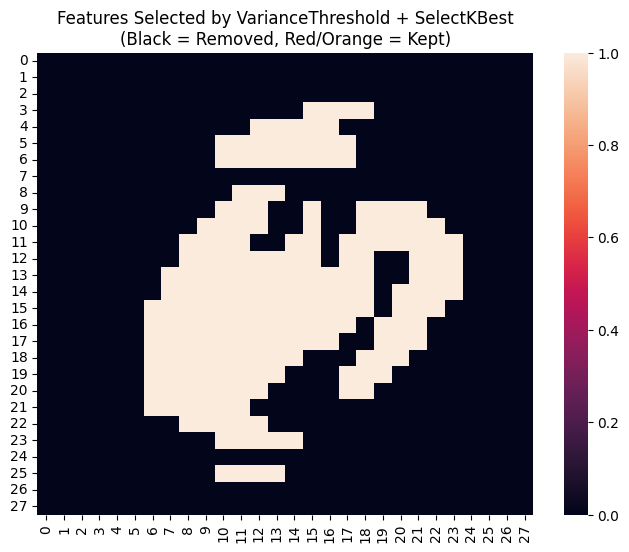

In [9]:
# Combine feature selection results and visualize
new_features_indices = variance_selector.get_support(indices=True)[selector.get_support()]
new_features_boolean = np.isin(np.arange(784), new_features_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(new_features_boolean.reshape(28,28), cmap='rocket')
plt.title("Features Selected by VarianceThreshold + SelectKBest\n(Black = Removed, Red/Orange = Kept)")
plt.show()

## Part Four: Recursive Feature Elimination using RFECV

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_selection import RFECV

# Standardize data
scaler = StandardScaler()
X_train_fs = scaler.fit_transform(X_train_fs)
X_test_fs = scaler.transform(X_test_fs)

print("Data standardized")

Data standardized


In [11]:
# Recursive Feature Elimination with Cross Validation
rf = RandomForestClassifier(random_state=0)
rfecv = RFECV(rf, cv=3, step=5)

print("Starting RFECV - this may take a few minutes...")
X_train_fs = rfecv.fit_transform(X_train_fs, y_train)
X_test_fs = rfecv.transform(X_test_fs)

print(f"Number of remaining features: {X_train_fs.shape[1]}")

Starting RFECV - this may take a few minutes...
Number of remaining features: 195


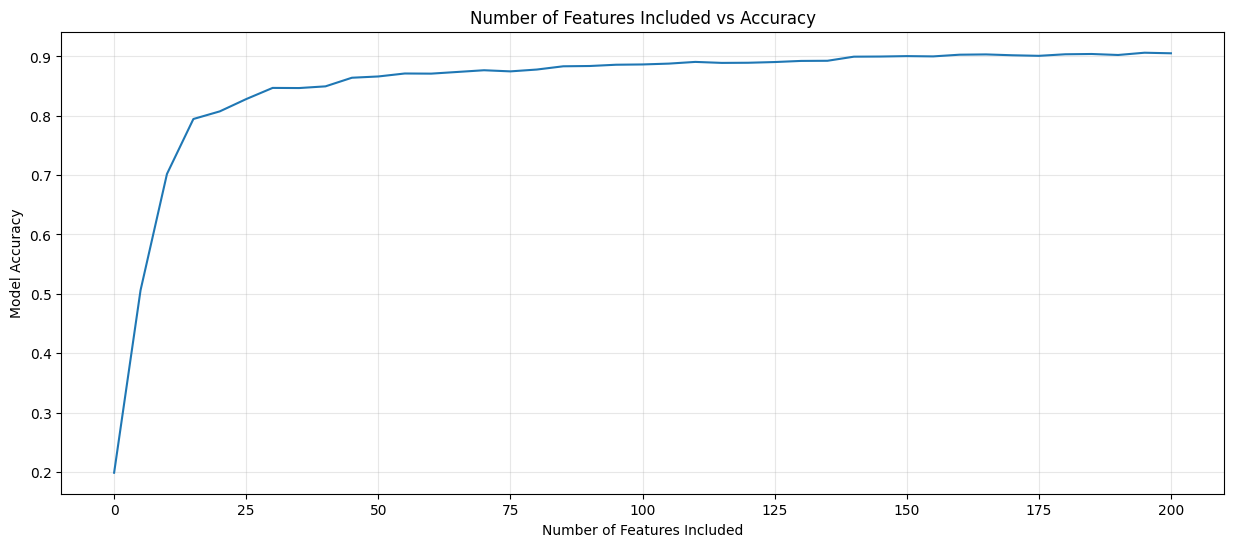

In [12]:
# Plot feature selection results
plt.figure(figsize=(15, 6))
plt.title('Number of Features Included vs Accuracy')
plt.xlabel('Number of Features Included')
plt.ylabel('Model Accuracy')
plt.plot(np.linspace(0,200,41), rfecv.cv_results_['mean_test_score'])
plt.grid(True, alpha=0.3)
plt.show()

## Part Five: Training and Evaluating a Model

In [13]:
# Train Random Forest on selected features
rf_selectedfeatures = RandomForestClassifier(random_state=0)
rf_selectedfeatures.fit(X_train_fs, y_train)

print("Model trained successfully")

Model trained successfully


In [14]:
# Make predictions and evaluate
y_pred = rf_selectedfeatures.predict(X_test_fs)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy*100:.2f}%")

Accuracy Score: 91.44%


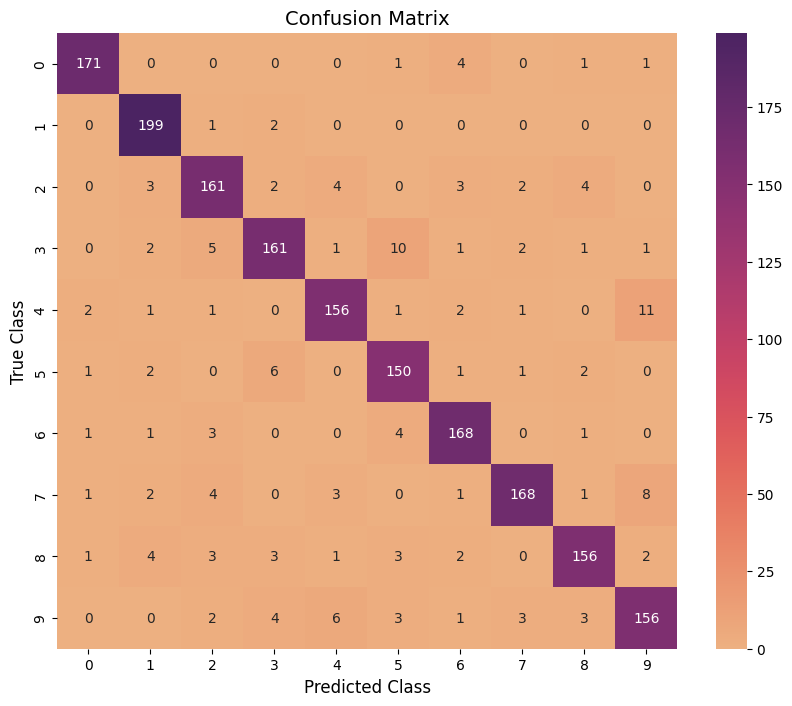

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm, cmap='flare', annot=True, fmt='d')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.show()

## Part Six: Addressing Class Imbalance

In [17]:
# Install imbalanced-learn if needed
!pip install -U imbalanced-learn

  Using cached imbalanced_learn-0.12.4-py3-none-any.whl.metadata (8.3 kB)
Using cached imbalanced_learn-0.12.4-py3-none-any.whl (258 kB)


In [18]:
import imblearn
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

print("Imbalanced-learn imported successfully")

Imbalanced-learn imported successfully


In [19]:
# Load cardio data
cardio_data = pd.read_csv('Cardiotocographic.csv')

# Explore data
print("First few rows:")
print(cardio_data.head())
print("\nLast few rows:")
print(cardio_data.tail())
print("\nClass distribution:")
print(cardio_data['NSP'].value_counts())

First few rows:
   BPM       APC  FMPS      UCPS      DLPS  SDPS  PDPS  ASTV  MSTV  ALTV  \
0  120  0.000000   0.0  0.000000  0.000000   0.0   0.0    73   0.5    43   
1  132  0.006380   0.0  0.006380  0.003190   0.0   0.0    17   2.1     0   
2  133  0.003322   0.0  0.008306  0.003322   0.0   0.0    16   2.1     0   
3  134  0.002561   0.0  0.007682  0.002561   0.0   0.0    16   2.4     0   
4  132  0.006515   0.0  0.008143  0.000000   0.0   0.0    16   2.4     0   

   MLTV  Width  Min  Max  NSP  
0   2.4     64   62  126    2  
1  10.4    130   68  198    1  
2  13.4    130   68  198    1  
3  23.0    117   53  170    1  
4  19.9    117   53  170    1  

Last few rows:
      BPM       APC      FMPS      UCPS  DLPS  SDPS  PDPS  ASTV  MSTV  ALTV  \
2121  140  0.000000  0.000000  0.007426   0.0   0.0   0.0    79   0.2    25   
2122  140  0.000775  0.000000  0.006971   0.0   0.0   0.0    78   0.4    22   
2123  140  0.000980  0.000000  0.006863   0.0   0.0   0.0    79   0.4    20   
212

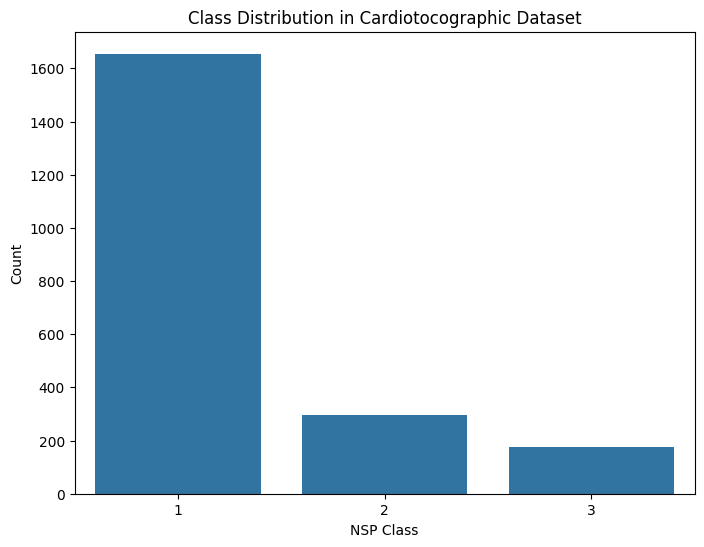

In [20]:
# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=cardio_data, x="NSP")
plt.title("Class Distribution in Cardiotocographic Dataset")
plt.xlabel("NSP Class")
plt.ylabel("Count")
plt.show()

In [21]:
# Prepare data for class imbalance handling
X = cardio_data.drop('NSP', axis=1)
y = cardio_data['NSP'] - 1  # Adjust labels to start from 0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training class distribution: {np.bincount(y_train)}")

Training set shape: (1700, 14)
Test set shape: (426, 14)
Training class distribution: [1323  236  141]


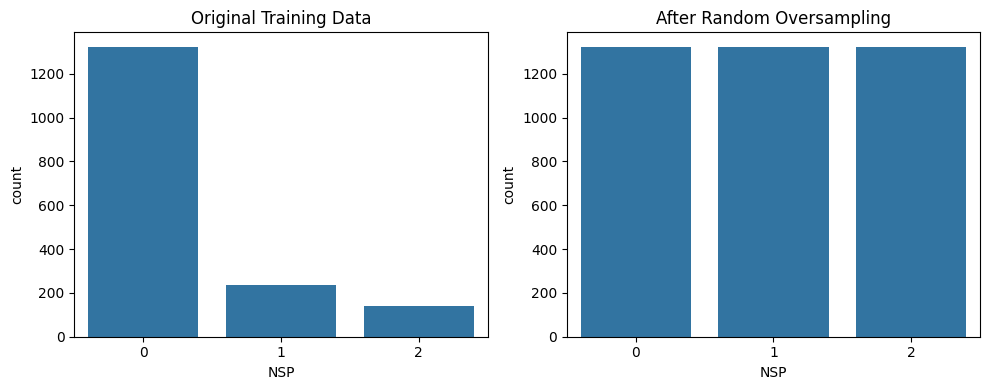

In [22]:
# Random Oversampling
resampler = RandomOverSampler(random_state=0)
X_train_oversampled, y_train_oversampled = resampler.fit_resample(X_train, y_train)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Original Training Data")
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_oversampled)
plt.title("After Random Oversampling")
plt.tight_layout()
plt.show()

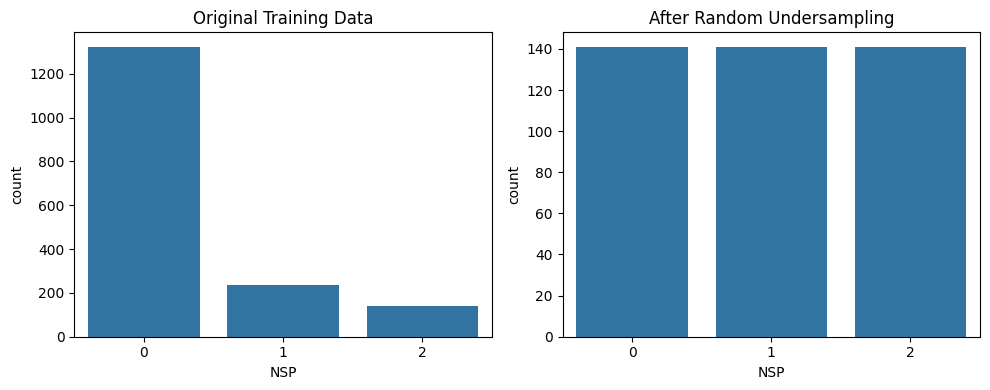

In [23]:
# Random Undersampling
resampler = RandomUnderSampler(random_state=0)
X_train_undersampled, y_train_undersampled = resampler.fit_resample(X_train, y_train)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Original Training Data")
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_undersampled)
plt.title("After Random Undersampling")
plt.tight_layout()
plt.show()

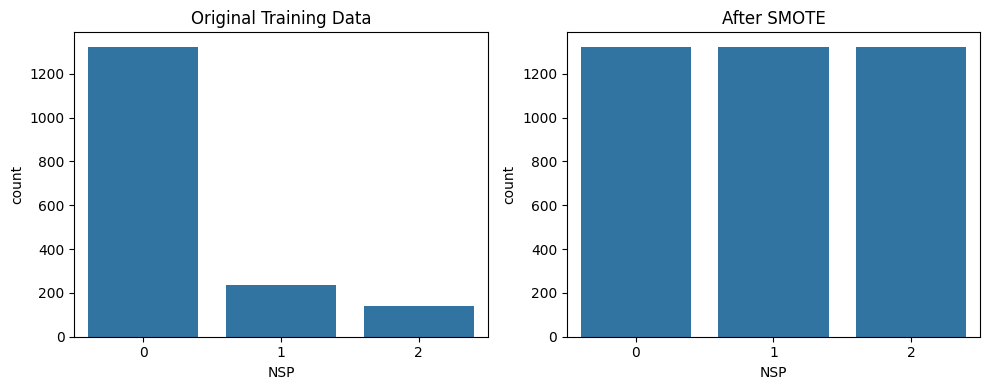

In [24]:
# SMOTE Oversampling
resampler = SMOTE(random_state=0)
X_train_smote, y_train_smote = resampler.fit_resample(X_train, y_train)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title("Original Training Data")
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote)
plt.title("After SMOTE")
plt.tight_layout()
plt.show()

## Summary

In this workshop, we have:

1. **Explored the MNIST dataset** and visualized handwritten digits
2. **Applied feature selection techniques**:
   - VarianceThreshold (removed 118 zero-variance features)
   - SelectKBest (selected top 200 features)
   - RFECV (wrapper method with cross-validation)
3. **Trained and evaluated a model** achieving over 90% accuracy with significantly reduced features
4. **Addressed class imbalance** using various resampling techniques:
   - Random Oversampling
   - Random Undersampling  
   - SMOTE (Synthetic Minority Over-sampling Technique)

The workshop demonstrates how feature selection can significantly reduce model complexity while maintaining high performance, and how resampling techniques can help address class imbalance issues in real-world datasets.